# Dark-matter detector mixture

This example infers the expected event counts of a continuum background and two spectral lines from synthetic xenon-detector observations. It analytically marginalises each event's category and integrates over continuum recoil energies with fixed quadrature. Spectral lines are monoenergetic before detector smearing.

The detector response is an illustrative, NEST-inspired approximation. Its constants require detector calibration before scientific use. See [NEST](https://github.com/NESTCollaboration/nest) for a detector-response model.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_probability.substrates.jax as tfp
from jax import random
from jax.scipy.special import erf, logsumexp
from jaxns.priors import Prior

from jaxns.core import NestedSampler
from jaxns.model import Model

tfpd = tfp.distributions

ENERGY_MIN_KEV = 1.0
ENERGY_MAX_KEV = 200.0
BACKGROUND_ENERGY_MIN_KEV = 50.0
BACKGROUND_ENERGY_MAX_KEV = 100.0
SIGNAL_ENERGY_KEV = 64.3
IODINE_ENERGY_KEV = 67.3
ELECTRIC_FIELD_V_PER_CM = 60.0
XENON_DENSITY_G_PER_CM3 = 2.8
S1_GAIN = 0.105
S2_GAIN = 31.8 * 0.5
S1_BASELINE_SIGMA = 3.0
S2_BASELINE_SIGMA = 120.0
S1_PHOTON_SIGMA = 0.4
S2_ELECTRON_SIGMA = 4.0
S1_S2_CORRELATION = -0.25
NUM_BACKGROUND_ENERGY_NODES = 96

/tmp/jaxns-288-api/src/jaxns/mixed_precision.py:14: UserWarning: JAX x64 is not enabled. Setting it now. Check for errors.
  warnings.warn("JAX x64 is not enabled. Setting it now. Check for errors.")


## A bounded response approximation

The mean electron and photon yields depend on recoil energy, electric field, and xenon density. We use them only on an explicit 1--200 keV support. Detector fluctuations are represented by a normalized correlated Gaussian in `(S1, S2)`, with strictly positive baseline resolution terms. The constants are illustrative and need calibration before scientific use.

In [2]:
def calculate_yield_parameters(electric_field_v_per_cm):
    field = electric_field_v_per_cm
    m01 = 30.66 + (6.1978 - 30.66) / (
        1.0 + (field / 73.855) ** 2.0318
    ) ** 0.41883
    m02 = 77.2931084
    m03 = jnp.log10(field) * 0.13946236 + 0.52561312
    m04 = 1.82217496 + (2.82528809 - 1.82217496) / (
        1.0 + (field / 144.65029656) ** -2.80532006
    )
    m07 = 7.02921301 + (98.27936794 - 7.02921301) / (
        1.0 + (field / 256.48156448) ** 1.29119251
    )
    m08 = 4.285781736
    m09 = 0.3344049589
    m10 = 0.0508273937 + (0.1166087199 - 0.0508273937) / (
        1.0 + (field / 139.260460) ** -0.65763592
    )
    return m01, m02, m03, m04, m07, m08, m09, m10


def work_function(density_g_per_cm3):
    molar_mass = 131.293
    avogadro = 6.0221409e23
    atomic_number = 54.0
    alpha = 0.067366 + density_g_per_cm3 * 0.039693
    electron_density = (
        density_g_per_cm3 / molar_mass * avogadro * atomic_number
    )
    work_function_ev = 1.1716263232 * (
        18.7263 - 1.01e-23 * electron_density
    )
    return work_function_ev, alpha


def mean_xenon_quanta(energy_kev):
    work_function_ev, alpha = work_function(XENON_DENSITY_G_PER_CM3)
    exciton_ion_ratio = alpha * erf(0.05 * energy_kev)
    m01, m02, m03, m04, m07, m08, m09, m10 = (
        calculate_yield_parameters(ELECTRIC_FIELD_V_PER_CM)
    )
    mean_num_quanta = energy_kev / work_function_ev * 1_000.0
    m05 = (
        mean_num_quanta / energy_kev / (1.0 + exciton_ion_ratio) - m01
    )
    charge_yield = (
        m01
        + (m02 - m01) / (1.0 + (energy_kev / m03) ** m04) ** m09
        + m05
        - m05 / (1.0 + (energy_kev / m07) ** m08) ** m10
    )

    # Preserve the density correction used by the source approximation.
    reference_density = 2.9
    coefficient_ti = (1.0 / reference_density) ** 0.3
    coefficient_ni = (1.0 / reference_density) ** 1.4
    coefficient_ol = (
        (1.0 / reference_density) ** -1.7
        / jnp.log(
            1.0
            + coefficient_ti
            * coefficient_ni
            * reference_density ** 1.7
        )
    )
    charge_yield *= (
        coefficient_ol
        * jnp.log(
            1.0
            + coefficient_ti
            * coefficient_ni
            * XENON_DENSITY_G_PER_CM3 ** 1.7
        )
        * XENON_DENSITY_G_PER_CM3 ** -1.7
    )
    mean_num_electrons = charge_yield * energy_kev
    mean_num_photons = mean_num_quanta - mean_num_electrons
    return mean_num_photons, mean_num_electrons


def response_moments(energy_kev):
    mean_num_photons, mean_num_electrons = mean_xenon_quanta(energy_kev)
    mean_s1 = S1_GAIN * mean_num_photons
    mean_s2 = S2_GAIN * mean_num_electrons
    sigma_s1 = jnp.sqrt(
        S1_BASELINE_SIGMA ** 2
        + S1_PHOTON_SIGMA ** 2 * mean_num_photons
    )
    sigma_s2 = jnp.sqrt(
        S2_BASELINE_SIGMA ** 2
        + S2_ELECTRON_SIGMA ** 2 * mean_num_electrons
    )
    return mean_s1, mean_s2, sigma_s1, sigma_s2


def response_log_prob(observations, energy_kev):
    mean_s1, mean_s2, sigma_s1, sigma_s2 = response_moments(energy_kev)
    observed_s1 = observations[..., 0]
    observed_s2 = observations[..., 1]
    z_s1 = (observed_s1 - mean_s1) / sigma_s1
    z_s2 = (observed_s2 - mean_s2) / sigma_s2
    one_minus_rho_squared = 1.0 - S1_S2_CORRELATION ** 2
    quadratic = (
        z_s1 ** 2
        - 2.0 * S1_S2_CORRELATION * z_s1 * z_s2
        + z_s2 ** 2
    ) / one_minus_rho_squared
    log_normalisation = (
        -jnp.log(2.0 * jnp.pi)
        - jnp.log(sigma_s1)
        - jnp.log(sigma_s2)
        - 0.5 * jnp.log(one_minus_rho_squared)
    )
    return log_normalisation - 0.5 * quadratic

## Marginal mixture likelihood

The likelihood is an extended mixture: a Poisson term models the observed count, and every event is evaluated under all three components. Categories are summed with `logsumexp`; they are not sampled. A 96-point Gauss--Legendre rule integrates the uniform continuum, while the two line responses are evaluated directly.

In [3]:
def make_background_energy_quadrature(num_nodes):
    abscissae, weights = np.polynomial.legendre.leggauss(num_nodes)
    unit_nodes = jnp.asarray((abscissae + 1.0) / 2.0)
    energy_nodes_kev = (
        BACKGROUND_ENERGY_MIN_KEV
        + (BACKGROUND_ENERGY_MAX_KEV - BACKGROUND_ENERGY_MIN_KEV)
        * unit_nodes
    )
    return energy_nodes_kev, jnp.log(jnp.asarray(weights / 2.0))


BACKGROUND_ENERGY_NODES_KEV, BACKGROUND_ENERGY_LOG_WEIGHTS = (
    make_background_energy_quadrature(NUM_BACKGROUND_ENERGY_NODES)
)


def component_event_log_prob(
    observations,
    energy_nodes_kev=BACKGROUND_ENERGY_NODES_KEV,
    energy_log_weights=BACKGROUND_ENERGY_LOG_WEIGHTS,
):
    # Only the continuum needs integration; both line components are
    # monoenergetic before detector smearing.
    background_log_prob = logsumexp(
        response_log_prob(observations, energy_nodes_kev[:, None])
        + energy_log_weights[:, None],
        axis=0,
    )
    signal_log_prob = response_log_prob(observations, SIGNAL_ENERGY_KEV)
    iodine_log_prob = response_log_prob(observations, IODINE_ENERGY_KEV)
    return jnp.stack(
        [background_log_prob, signal_log_prob, iodine_log_prob],
        axis=0,
    )


def log_likelihood(component_events, component_log_density):
    total_events = jnp.sum(component_events)
    log_component_fraction = (
        jnp.log(component_events) - jnp.log(total_events)
    )
    event_log_prob = logsumexp(
        log_component_fraction[:, None]
        + component_log_density,
        axis=0,
    )
    count_log_prob = tfpd.Poisson(rate=total_events).log_prob(
        component_log_density.shape[1]
    )
    return count_log_prob + jnp.sum(event_log_prob)


def simulate_observations(key, true_component_events):
    count_key, category_key, energy_key, noise_key = random.split(key, 4)
    num_events = int(
        tfpd.Poisson(rate=jnp.sum(true_component_events)).sample(
            seed=count_key
        )
    )
    categories = random.categorical(
        category_key,
        jnp.log(true_component_events),
        shape=(num_events,),
    )
    background_energies = tfpd.Uniform(
        low=BACKGROUND_ENERGY_MIN_KEV,
        high=BACKGROUND_ENERGY_MAX_KEV,
    ).sample(num_events, seed=energy_key)
    component_energies = jnp.stack(
        [
            background_energies,
            jnp.full((num_events,), SIGNAL_ENERGY_KEV),
            jnp.full((num_events,), IODINE_ENERGY_KEV),
        ]
    )
    energies = component_energies[categories, jnp.arange(num_events)]
    mean_s1, mean_s2, sigma_s1, sigma_s2 = response_moments(energies)
    independent_noise = random.normal(noise_key, shape=(num_events, 2))
    s1_noise = independent_noise[:, 0]
    s2_noise = (
        S1_S2_CORRELATION * s1_noise
        + jnp.sqrt(1.0 - S1_S2_CORRELATION ** 2)
        * independent_noise[:, 1]
    )
    observations = jnp.stack(
        [
            mean_s1 + sigma_s1 * s1_noise,
            mean_s2 + sigma_s2 * s2_noise,
        ],
        axis=-1,
    )
    return observations, categories

Observed events: 46
96-vs-256 node maximum log-likelihood difference: 0.000270


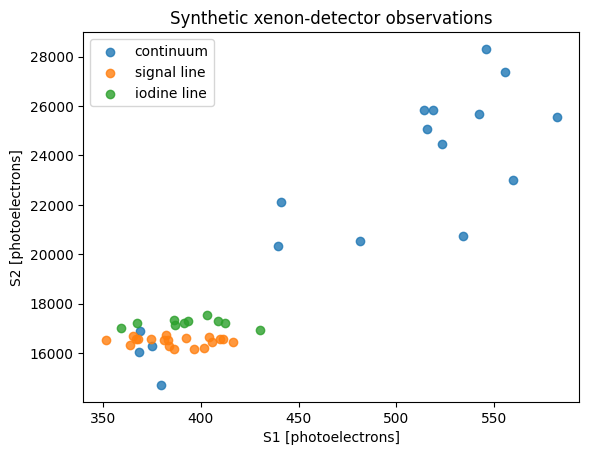

In [4]:
component_names = ("continuum", "signal line", "iodine line")
true_component_events = jnp.asarray([20.0, 15.0, 10.0])
observations, simulated_categories = simulate_observations(
    random.PRNGKey(20260829),
    true_component_events,
)

# Check the entire declared response support, not just the quadrature nodes.
energy_grid_kev = jnp.linspace(ENERGY_MIN_KEV, ENERGY_MAX_KEV, 10_000)
response_values = jnp.stack(response_moments(energy_grid_kev))
assert bool(jnp.all(jnp.isfinite(response_values)))
assert bool(jnp.all(response_values > 0.0))
assert np.isclose(
    float(jnp.sum(jnp.exp(BACKGROUND_ENERGY_LOG_WEIGHTS))),
    1.0,
)

# The response table is fixed for this data set, so compute it once rather
# than rebuilding it inside every likelihood evaluation.
component_log_density = component_event_log_prob(observations)

# Compare against a higher-order rule across representative continuum-
# and line-dominated mixtures, not only at the simulation truth.
fine_nodes_kev, fine_log_weights = make_background_energy_quadrature(256)
fine_component_log_density = component_event_log_prob(
    observations,
    energy_nodes_kev=fine_nodes_kev,
    energy_log_weights=fine_log_weights,
)
quadrature_check_events = jnp.asarray(
    [
        true_component_events,
        [20.0, 20.0, 20.0],
        [40.0, 1.0, 1.0],
        [1.0, 40.0, 1.0],
        [1.0, 1.0, 40.0],
    ]
)
coarse_log_likelihoods = jnp.stack(
    [
        log_likelihood(events, component_log_density)
        for events in quadrature_check_events
    ]
)
fine_log_likelihoods = jnp.stack(
    [
        log_likelihood(events, fine_component_log_density)
        for events in quadrature_check_events
    ]
)
quadrature_difference = float(
    jnp.max(jnp.abs(coarse_log_likelihoods - fine_log_likelihoods))
)
assert quadrature_difference < 1e-3
print(f"Observed events: {observations.shape[0]}")
print(
    "96-vs-256 node maximum log-likelihood difference: "
    f"{quadrature_difference:.6f}"
)

for category, name in enumerate(component_names):
    selected = simulated_categories == category
    plt.scatter(
        observations[selected, 0],
        observations[selected, 1],
        label=name,
        alpha=0.8,
    )
plt.xlabel("S1 [photoelectrons]")
plt.ylabel("S2 [photoelectrons]")
plt.title("Synthetic xenon-detector observations")
plt.legend()
plt.show()

In [5]:
def prior_model(component_log_density):
    # These Gamma priors put each expected component count on the scale of
    # the synthetic exposure while retaining substantial uncertainty.
    background_events = Prior(
        tfpd.Gamma(concentration=2.0, rate=0.1),
        name="background_events",
    ).realise()
    signal_events = Prior(
        tfpd.Gamma(concentration=2.0, rate=0.1),
        name="signal_events",
    ).realise()
    iodine_events = Prior(
        tfpd.Gamma(concentration=2.0, rate=0.1),
        name="iodine_events",
    ).realise()
    component_events = jnp.stack(
        [background_events, signal_events, iodine_events]
    )
    return log_likelihood(component_events, component_log_density)


model = Model(prior_model=prior_model)
args = (component_log_density,)
model.sanity_check(
    random.PRNGKey(1),
    args=args,
    num_samples=2_048,
)
print("U-space dimensions:", model.U_ndims(args=args))

2026-09-28 10:25:28,754 INFO     model.py   jaxns: Sanity check...


2026-09-28 10:25:36,744 INFO     model.py   jaxns: Sanity check passed


U-space dimensions: 3


In [6]:
target_log_Z_uncert = 0.1


def evidence_precision_reached(state):
    return state.expected_log_Z_uncert <= target_log_Z_uncert


sampler = NestedSampler(
    model=model,
    collect_phantom_samples=True,
)
state = sampler.run_until_goal(
    goal_cond=evidence_precision_reached,
    args=args,
    key=random.PRNGKey(42),
)
results = state.to_result().trim()
results.summary()

--------
Run status:
No hard termination reason
--------
likelihood evals: 167290
classic samples: 3133
phantom samples: 9129
likelihood evals / sample: 53.4
--------
logZ (classic expected)=-616.066 +- 0.095
max(logL)=-612.352
H=2.3
posterior ESS (Kish)=1237.5


likelihood evals / posterior ESS: 135.2


--------
background_events: mean +- std.dev. | MAP est. | max(L) est.
background_events: 16.8 +- 4.2 | 15.7 | 16.4
--------
iodine_events: mean +- std.dev. | MAP est. | max(L) est.
iodine_events: 10.0 +- 3.3 | 9.2 | 9.2
--------
signal_events: mean +- std.dev. | MAP est. | max(L) est.
signal_events: 20.5 +- 4.6 | 19.5 | 20.4
--------


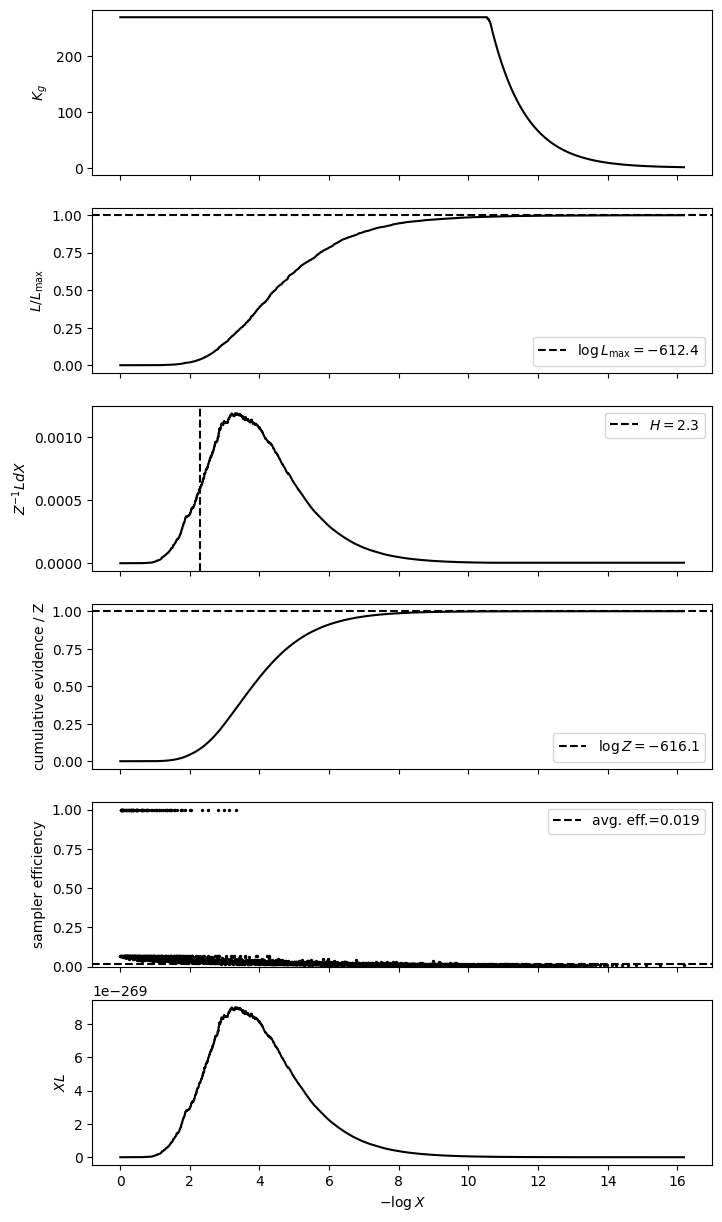

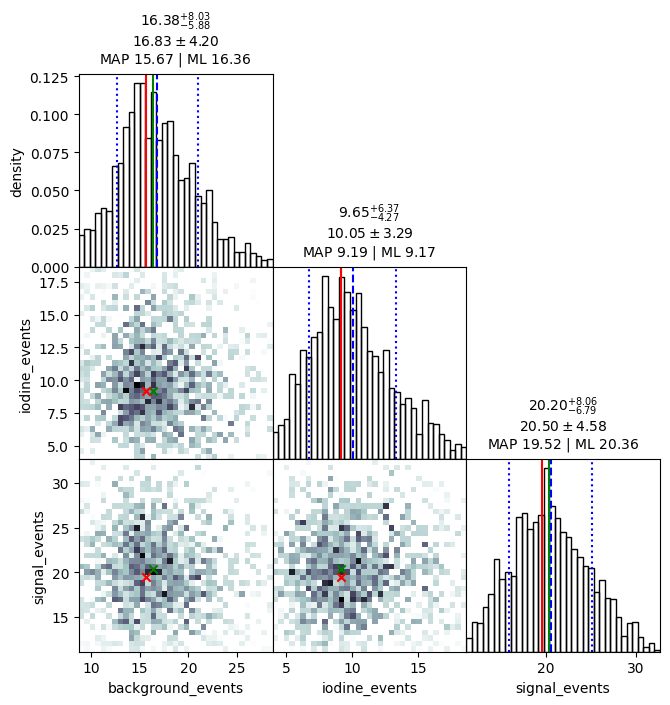

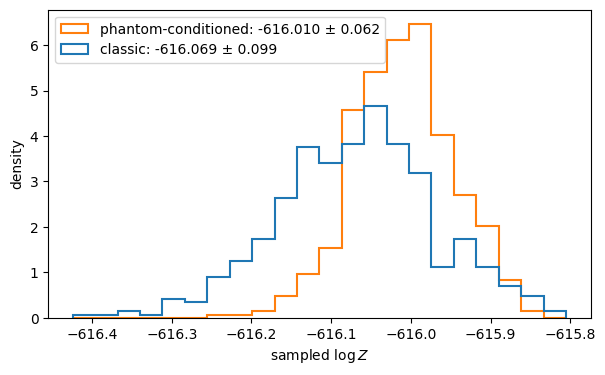

In [7]:
results.plot_diagnostics()
results.plot_cornerplot()
results.plot_evidence(
    num_samples=512,
    conditionings=("classic", "phantom"),
    key=random.PRNGKey(2),
)

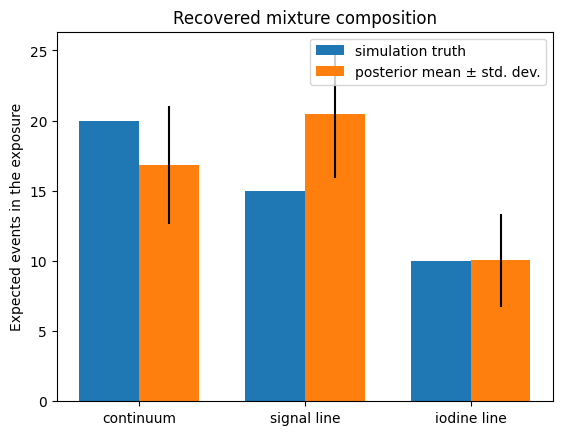

In [8]:
def component_count_moments(parameters):
    component_events = jnp.stack(
        [
            parameters["background_events"],
            parameters["signal_events"],
            parameters["iodine_events"],
        ]
    )
    return component_events, jnp.square(component_events)


posterior_mean, posterior_second_moment = (
    results.integrate_fn_over_posterior(
        component_count_moments,
        semi_positive=True,
    )
)
posterior_std = jnp.sqrt(
    jnp.maximum(
        0.0,
        posterior_second_moment - jnp.square(posterior_mean),
    )
)

x = np.arange(len(component_names))
plt.bar(x - 0.18, true_component_events, 0.36, label="simulation truth")
plt.bar(
    x + 0.18,
    posterior_mean,
    0.36,
    yerr=posterior_std,
    label="posterior mean ± std. dev.",
)
plt.xticks(x, component_names)
plt.ylabel("Expected events in the exposure")
plt.title("Recovered mixture composition")
plt.legend()
plt.show()

## Takeaway

A stable event likelihood has an explicit model domain, normalized component densities, positive resolution scales, and explicit units. Marginalising nuisance categories and recoil energies leaves only three expected event counts to sample. For scientific use, validate the response and fixed constants against the intended NEST release and detector calibration.